# Dimensional Method: CS-01 TAS

**Purpose**: characterise the Tele Assistance System dimensionally for every
adaptation (`baseline`, `s1`, `s2`, `aggregate`). For each artifact, PyDASA
derives Pi-groups from the 10 relevant variables (3 FDUs: `T`, `S`, `D`
meaning Time / Structure / Data), then four operationally meaningful
coefficients are built from them:

- $\theta = L/K$ &nbsp; **Occupancy** (queue fill ratio)
- $\sigma = W\lambda/K$ &nbsp; **Stall** (Little's-law residual; blocking)
- $\eta = \chi K/(\mu c)$ &nbsp; **Effective-yield** (utilisation headroom)
- $\phi = M_{act}/M_{buf}$ &nbsp; **Memory-usage** (buffer fill)

Outputs go under `data/results/dimensional/<scenario>/<profile>.json` and
figures under `data/img/dimensional/<scenario>/`.

**Equivalent CLI**:

```bash
python -m src.methods.dimensional --adaptation baseline
python -m src.methods.dimensional --adaptation s1 --profile opti
python -m src.methods.dimensional --adaptation s2 --profile opti
python -m src.methods.dimensional --adaptation aggregate --profile opti
```


In [1]:
%matplotlib inline

from pathlib import Path

import pandas as pd

from src.dimensional import (coefs_to_net,
                             coefs_to_nodes)
from src.methods.dimensional import run
from src.view import (plot_dim_topology,
                      plot_node_diffmap,
                      plot_node_heatmap,
                      plot_arch_bars,
                      plot_arch_delta)

# adaptation axis for the matrix
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# figure output root for this method
IMG_ROOT = Path("data/img/dimensional")

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

# label map for the four derived coefficients (\mathbf so Greek renders bold under matplotlib mathtext)
COEF_LABELS = {
    "theta": r"$\mathbf{\theta}$",
    "sigma": r"$\mathbf{\sigma}$",
    "eta": r"$\mathbf{\eta}$",
    "phi": r"$\mathbf{\phi}$",
}


## 1. Run the dimensional method on every adaptation

`run(adp=a, wrt=True)` loads the resolved `NetCfg`, builds one
`AnalysisEngine` per artifact, derives 7 Pi-groups, applies the 4 coefficient
specs from `data/config/method/dimensional.json`, and runs a symbolic
sensitivity pass. Result written to
`data/results/dimensional/<scenario>/<profile>.json`.


In [2]:
results = {a: run(adp=a, wrt=True) for a in ADAPTATIONS}


In [3]:
# unpack the per-adaptation per-node / network frames
nodes = {a: coefs_to_nodes(results[a]) for a in ADAPTATIONS}
nets = {a: coefs_to_net(results[a]) for a in ADAPTATIONS}

In [4]:
for a in ADAPTATIONS:
    cfg = results[a]["config"]
    print(f"{a:>10} -> profile={cfg.profile}  scenario={cfg.scenario}  "
          f"artifacts={len(results[a]['artifacts'])}")

  baseline -> profile=dflt  scenario=baseline  artifacts=13
        s1 -> profile=opti  scenario=s1  artifacts=13
        s2 -> profile=opti  scenario=s2  artifacts=13
 aggregate -> profile=opti  scenario=aggregate  artifacts=13


## 2. Network-wide coefficient summary

One row per adaptation. Aggregation is the **mean** across the 13 (or 16)
artifacts of that scenario; see `coefs_to_net(agg="median")` for
the robust view.


In [5]:
rows = []
for a in ADAPTATIONS:
    row = {"adaptation": a}
    row.update(nets[a].iloc[0].to_dict())
    rows.append(row)

pd.DataFrame(rows).set_index("adaptation")


,nodes,theta,sigma,eta,phi
adaptation,,,,,
baseline,13.0,0.056756,0.056898,2.890009,0.056756
s1,13.0,0.054738,0.054788,2.915065,0.054738
s2,13.0,0.053514,0.053640,2.940838,0.053514
aggregate,13.0,0.053981,0.054103,2.959735,0.053981


## 3. Per-node coefficient snapshot (baseline)

Reference cloud before any adaptation. Under the uniform baseline init
($L_{mean}=6$, $K_{mean}=10$, $M_{act}=L\delta$, $M_{buf}=K\delta$), $\theta$
and $\phi$ collapse to the same value $0.6$ on every artifact. $\sigma$ and
$\eta$ vary with the per-artifact service rate and error probability.


In [6]:
nodes["baseline"][["key", "name", "type", "theta", "sigma", "eta", "phi"]]


,key,name,type,theta,sigma,eta,phi
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,0.096724,0.096766,4.928571,0.096724
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,0.058621,0.058623,3.696429,0.058621
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,0.033137,0.033137,2.488929,0.033137
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,0.115719,0.115830,4.743750,0.115719
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,0.021726,0.021726,1.659906,0.021726
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,0.206804,0.208491,5.692500,0.206804
6,AS_{1},Alarm Service 1,M/M/s/K,0.010167,0.010167,0.821346,0.010167
7,AS_{2},Alarm Service 2,M/M/s/K,0.017716,0.017716,1.444793,0.017716
8,AS_{3},Alarm Service 3,M/M/s/K,0.004644,0.004644,0.363888,0.004644
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,0.058621,0.058623,3.696429,0.058621


## 4. Dimensionless topology (per adaptation)

Architecture diagram mirrored from the analytic method, but node colouring
and labels switch to the four dimensionless coefficients
($	heta, \sigma, \eta, \phi$) instead of queue metrics. Node colour
encodes $\sigma$ (Stall, queueing share of capacity); the per-node label
shows the artifact key plus $	heta$ (Occupancy). Full per-node coefficient
table sits below the graph. Every adaptation gets its own topology.png
under data/img/dimensional/<adp>/.


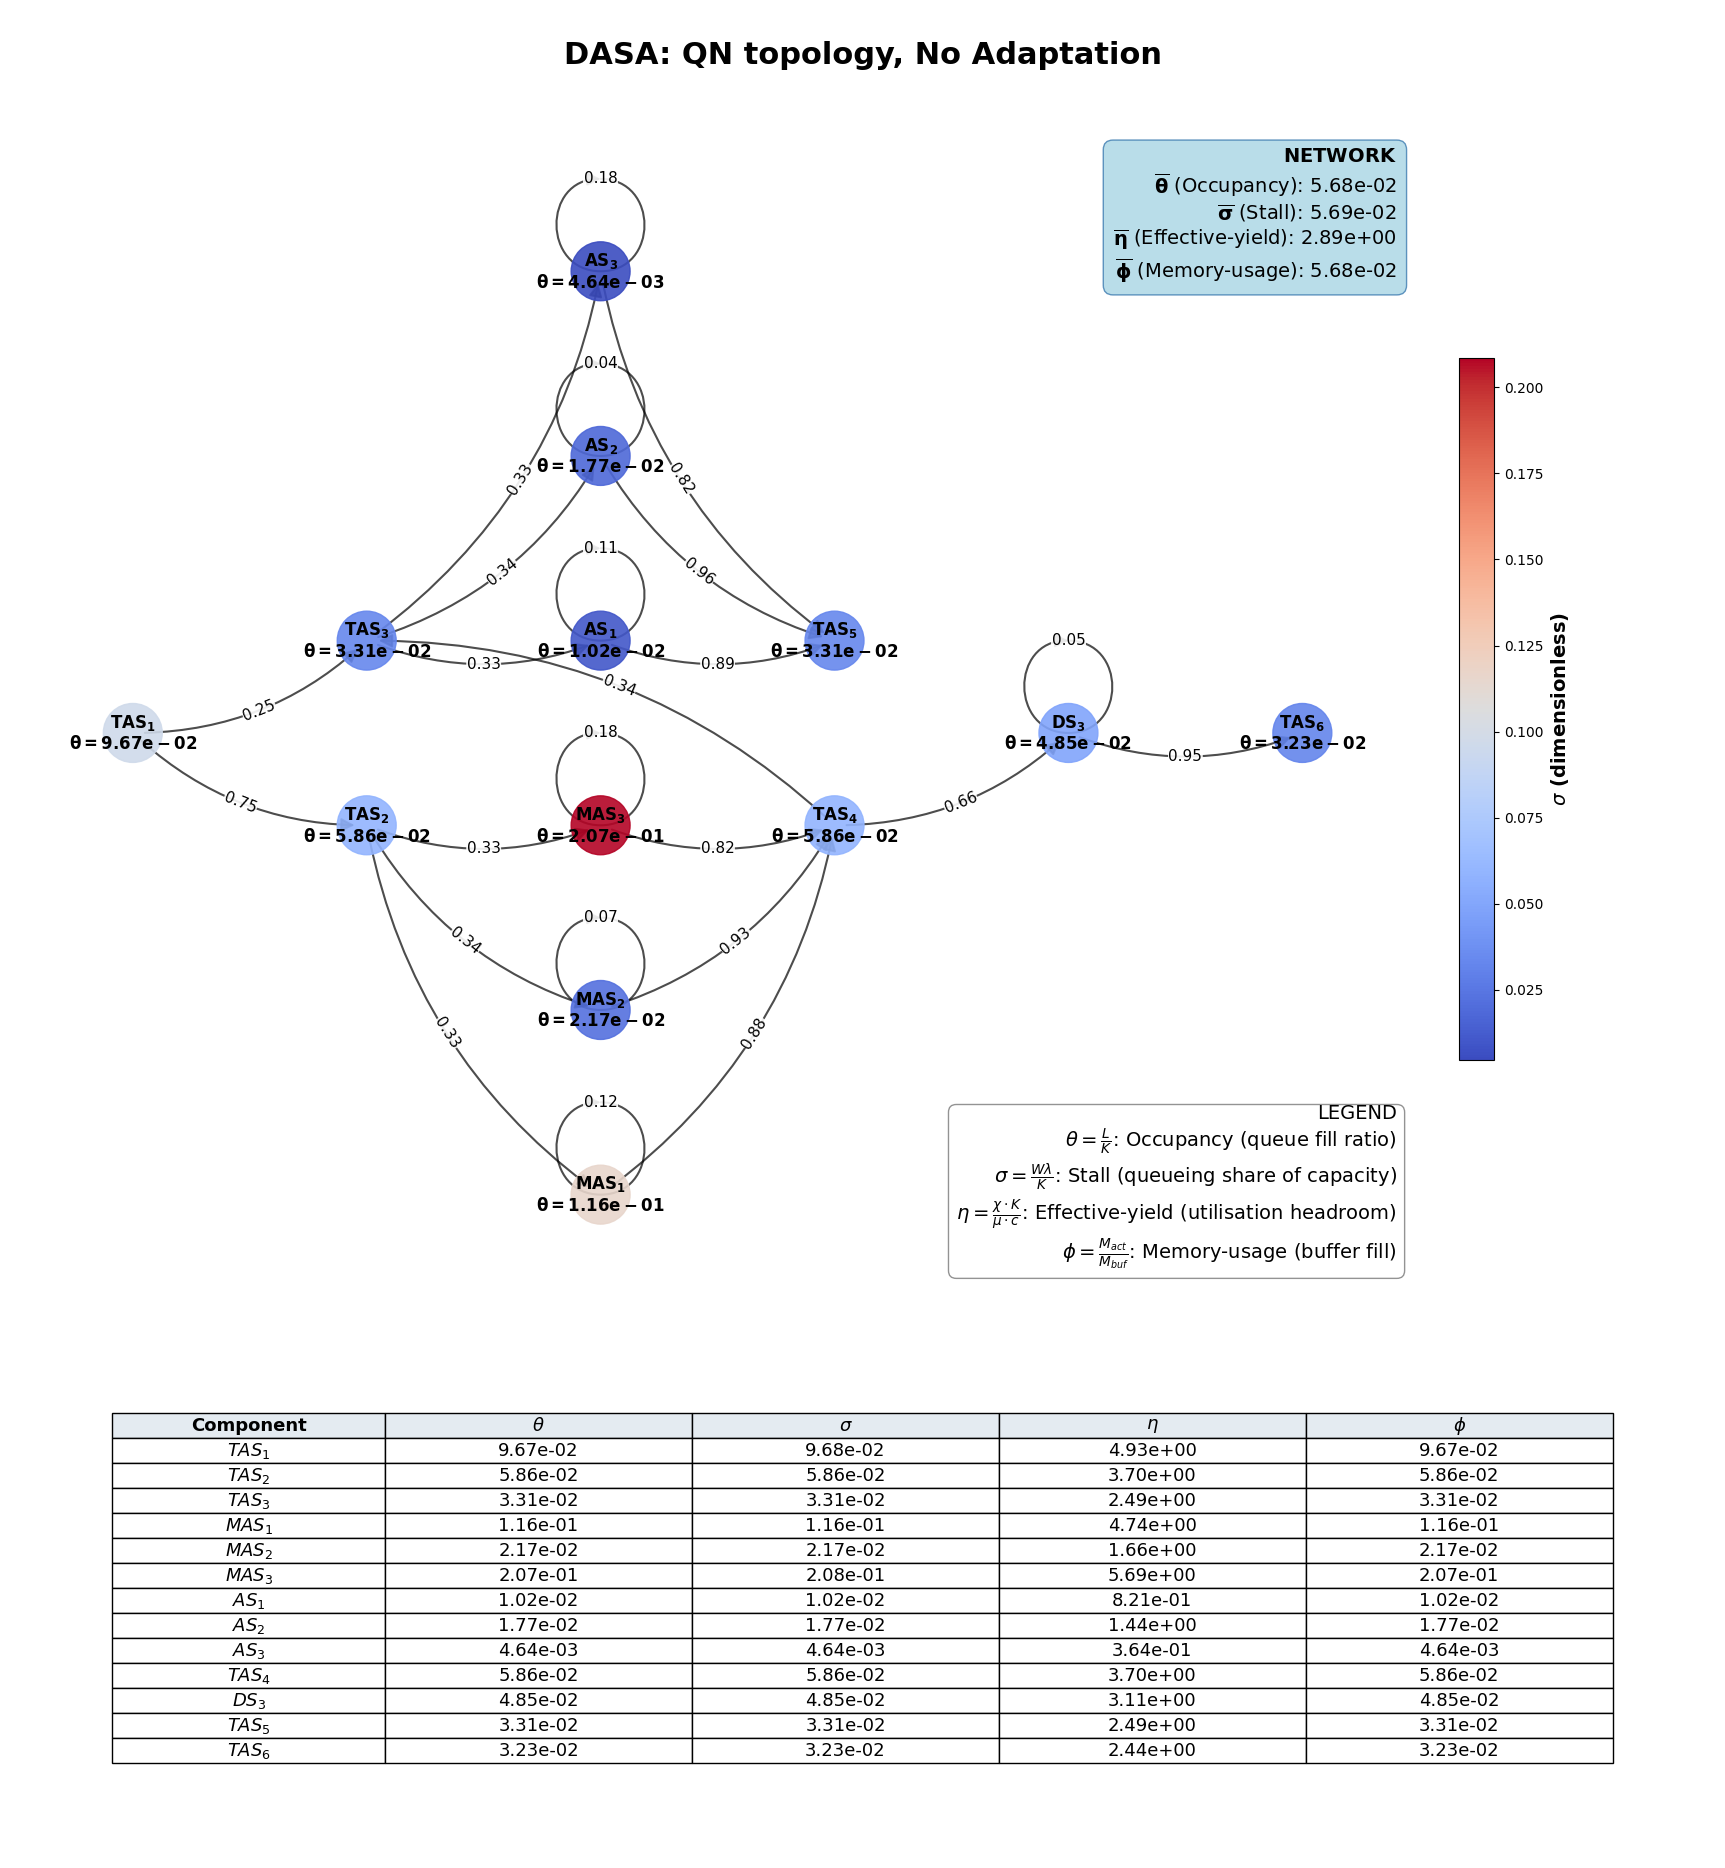

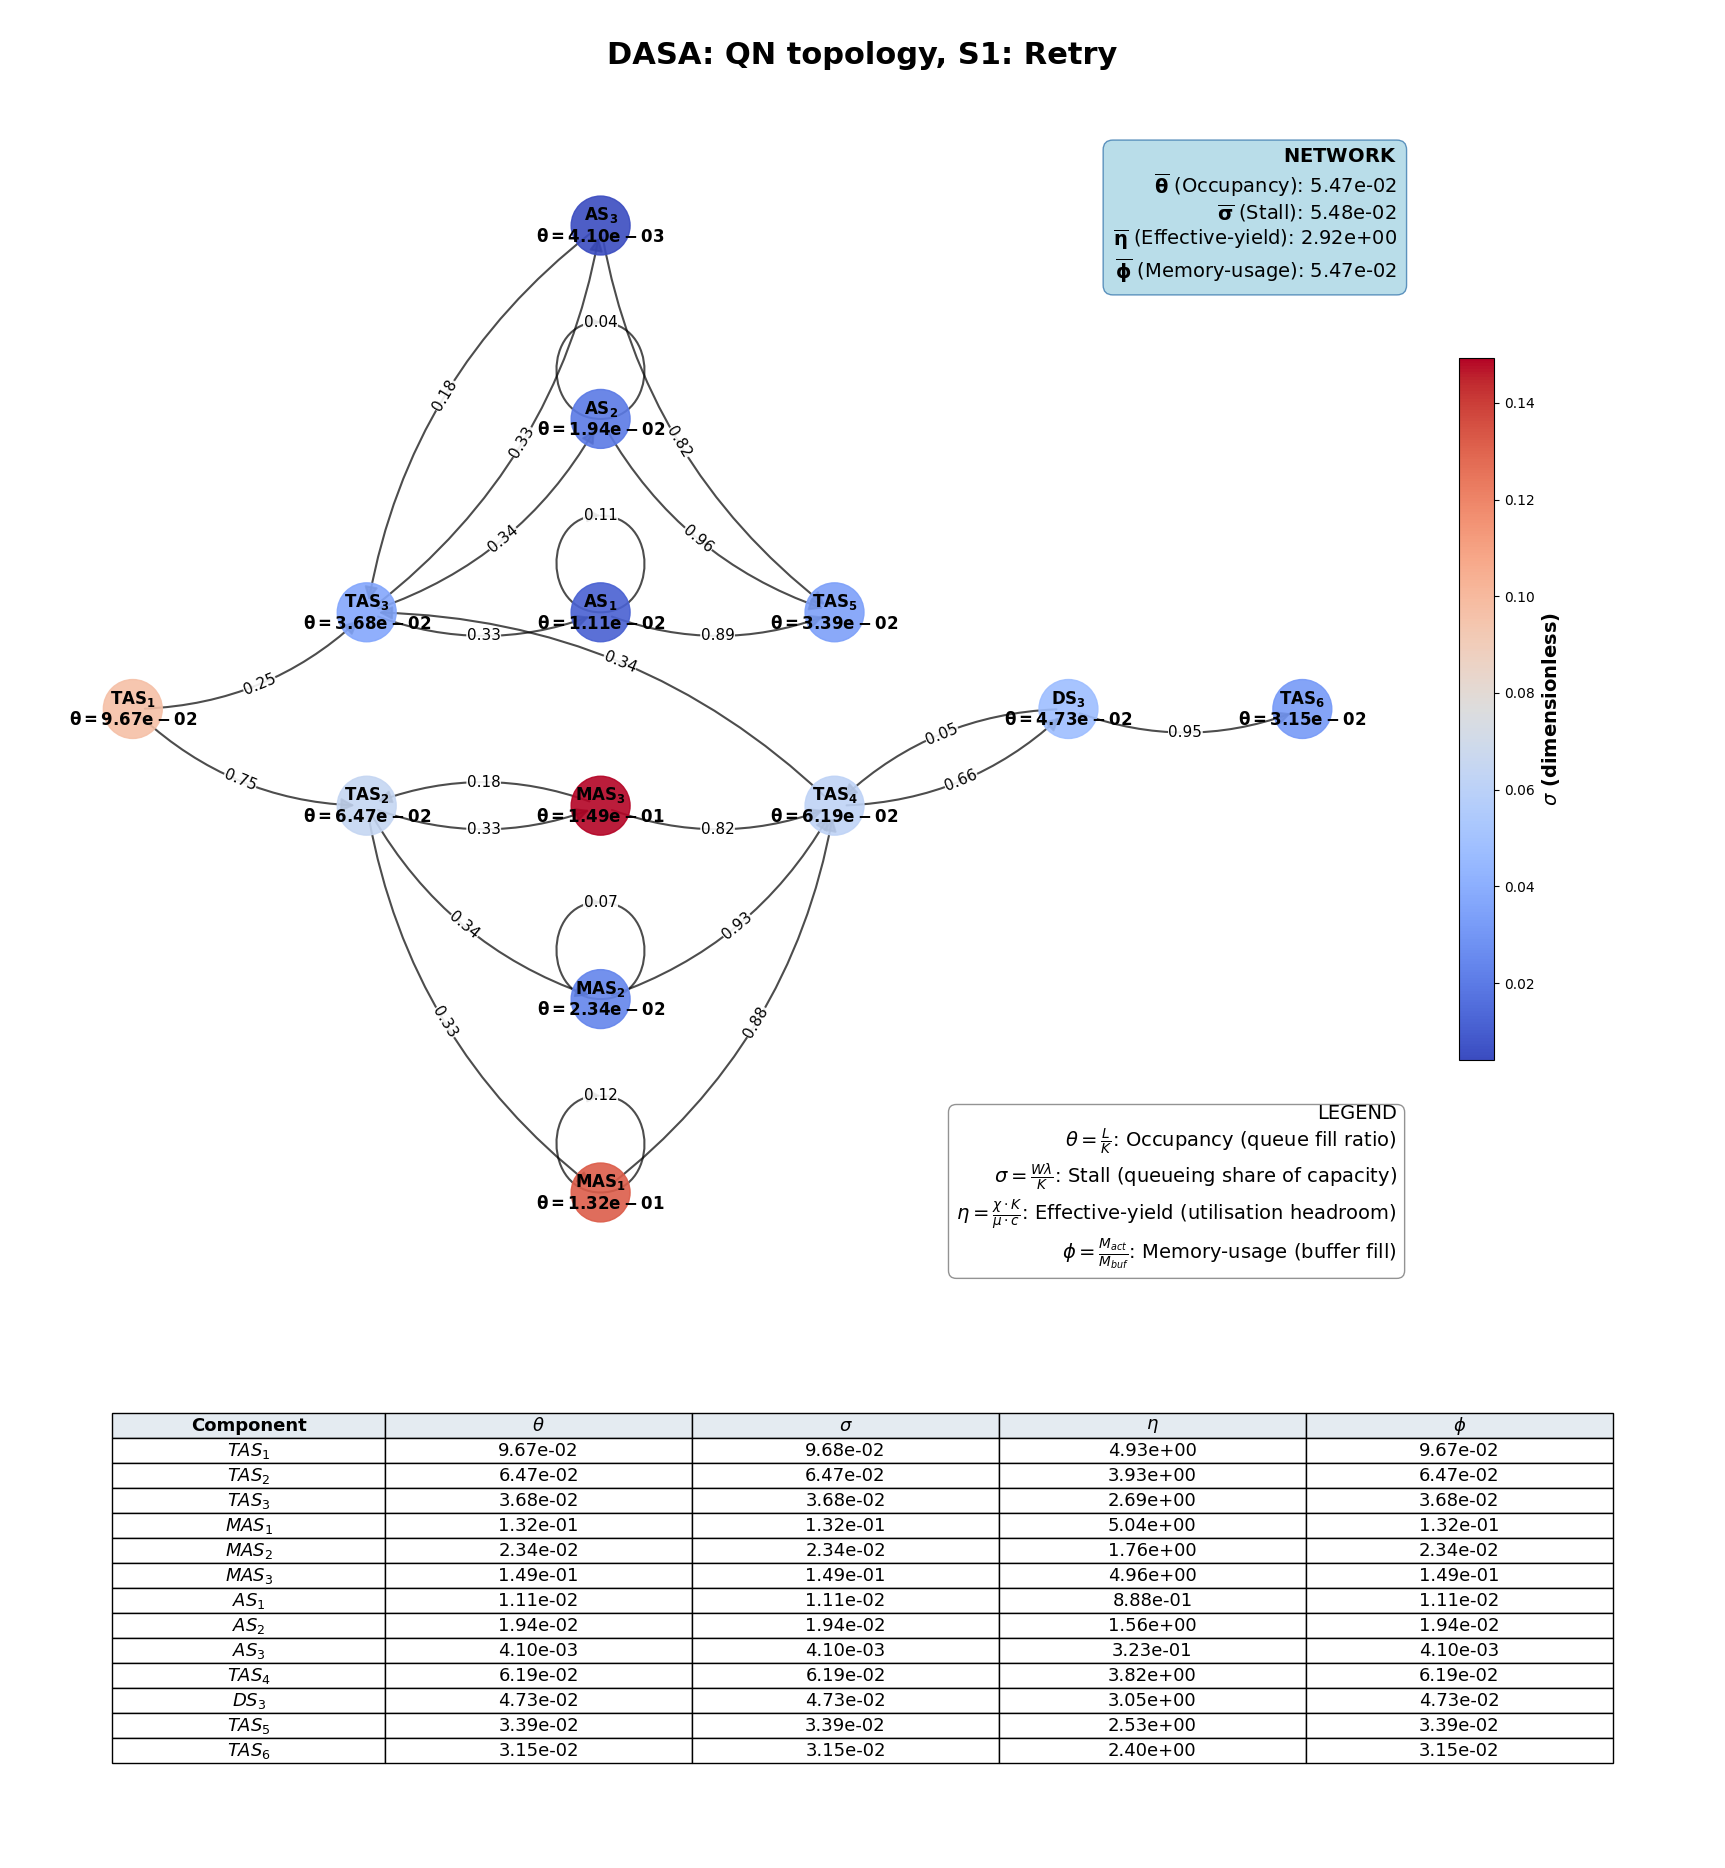

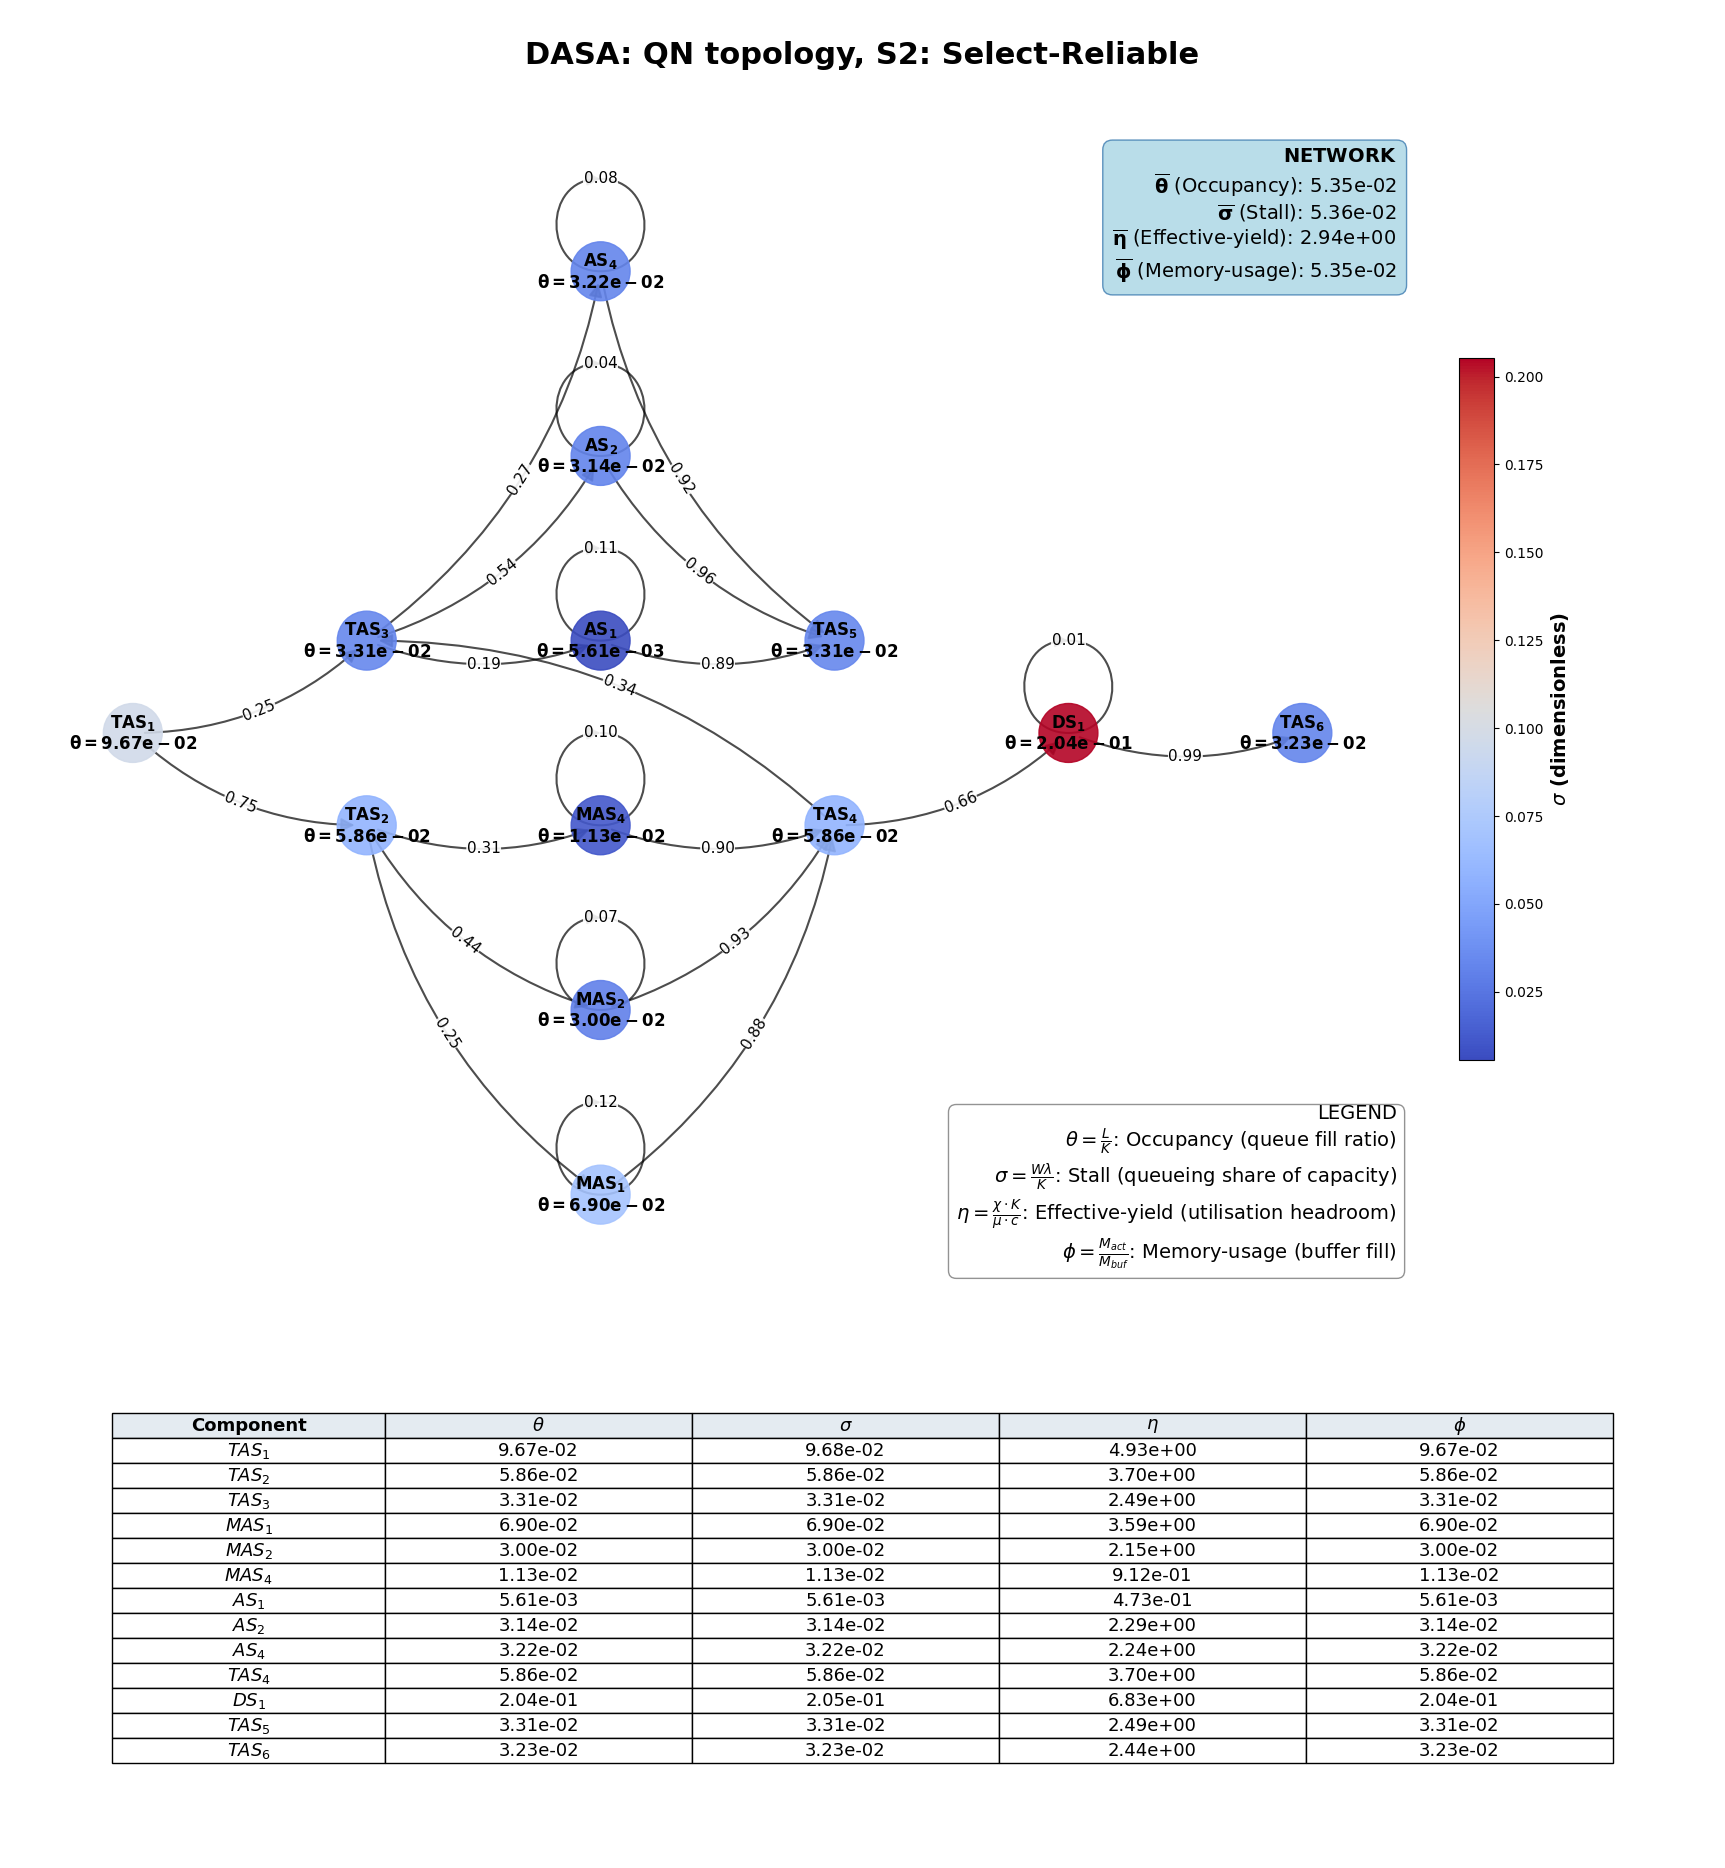

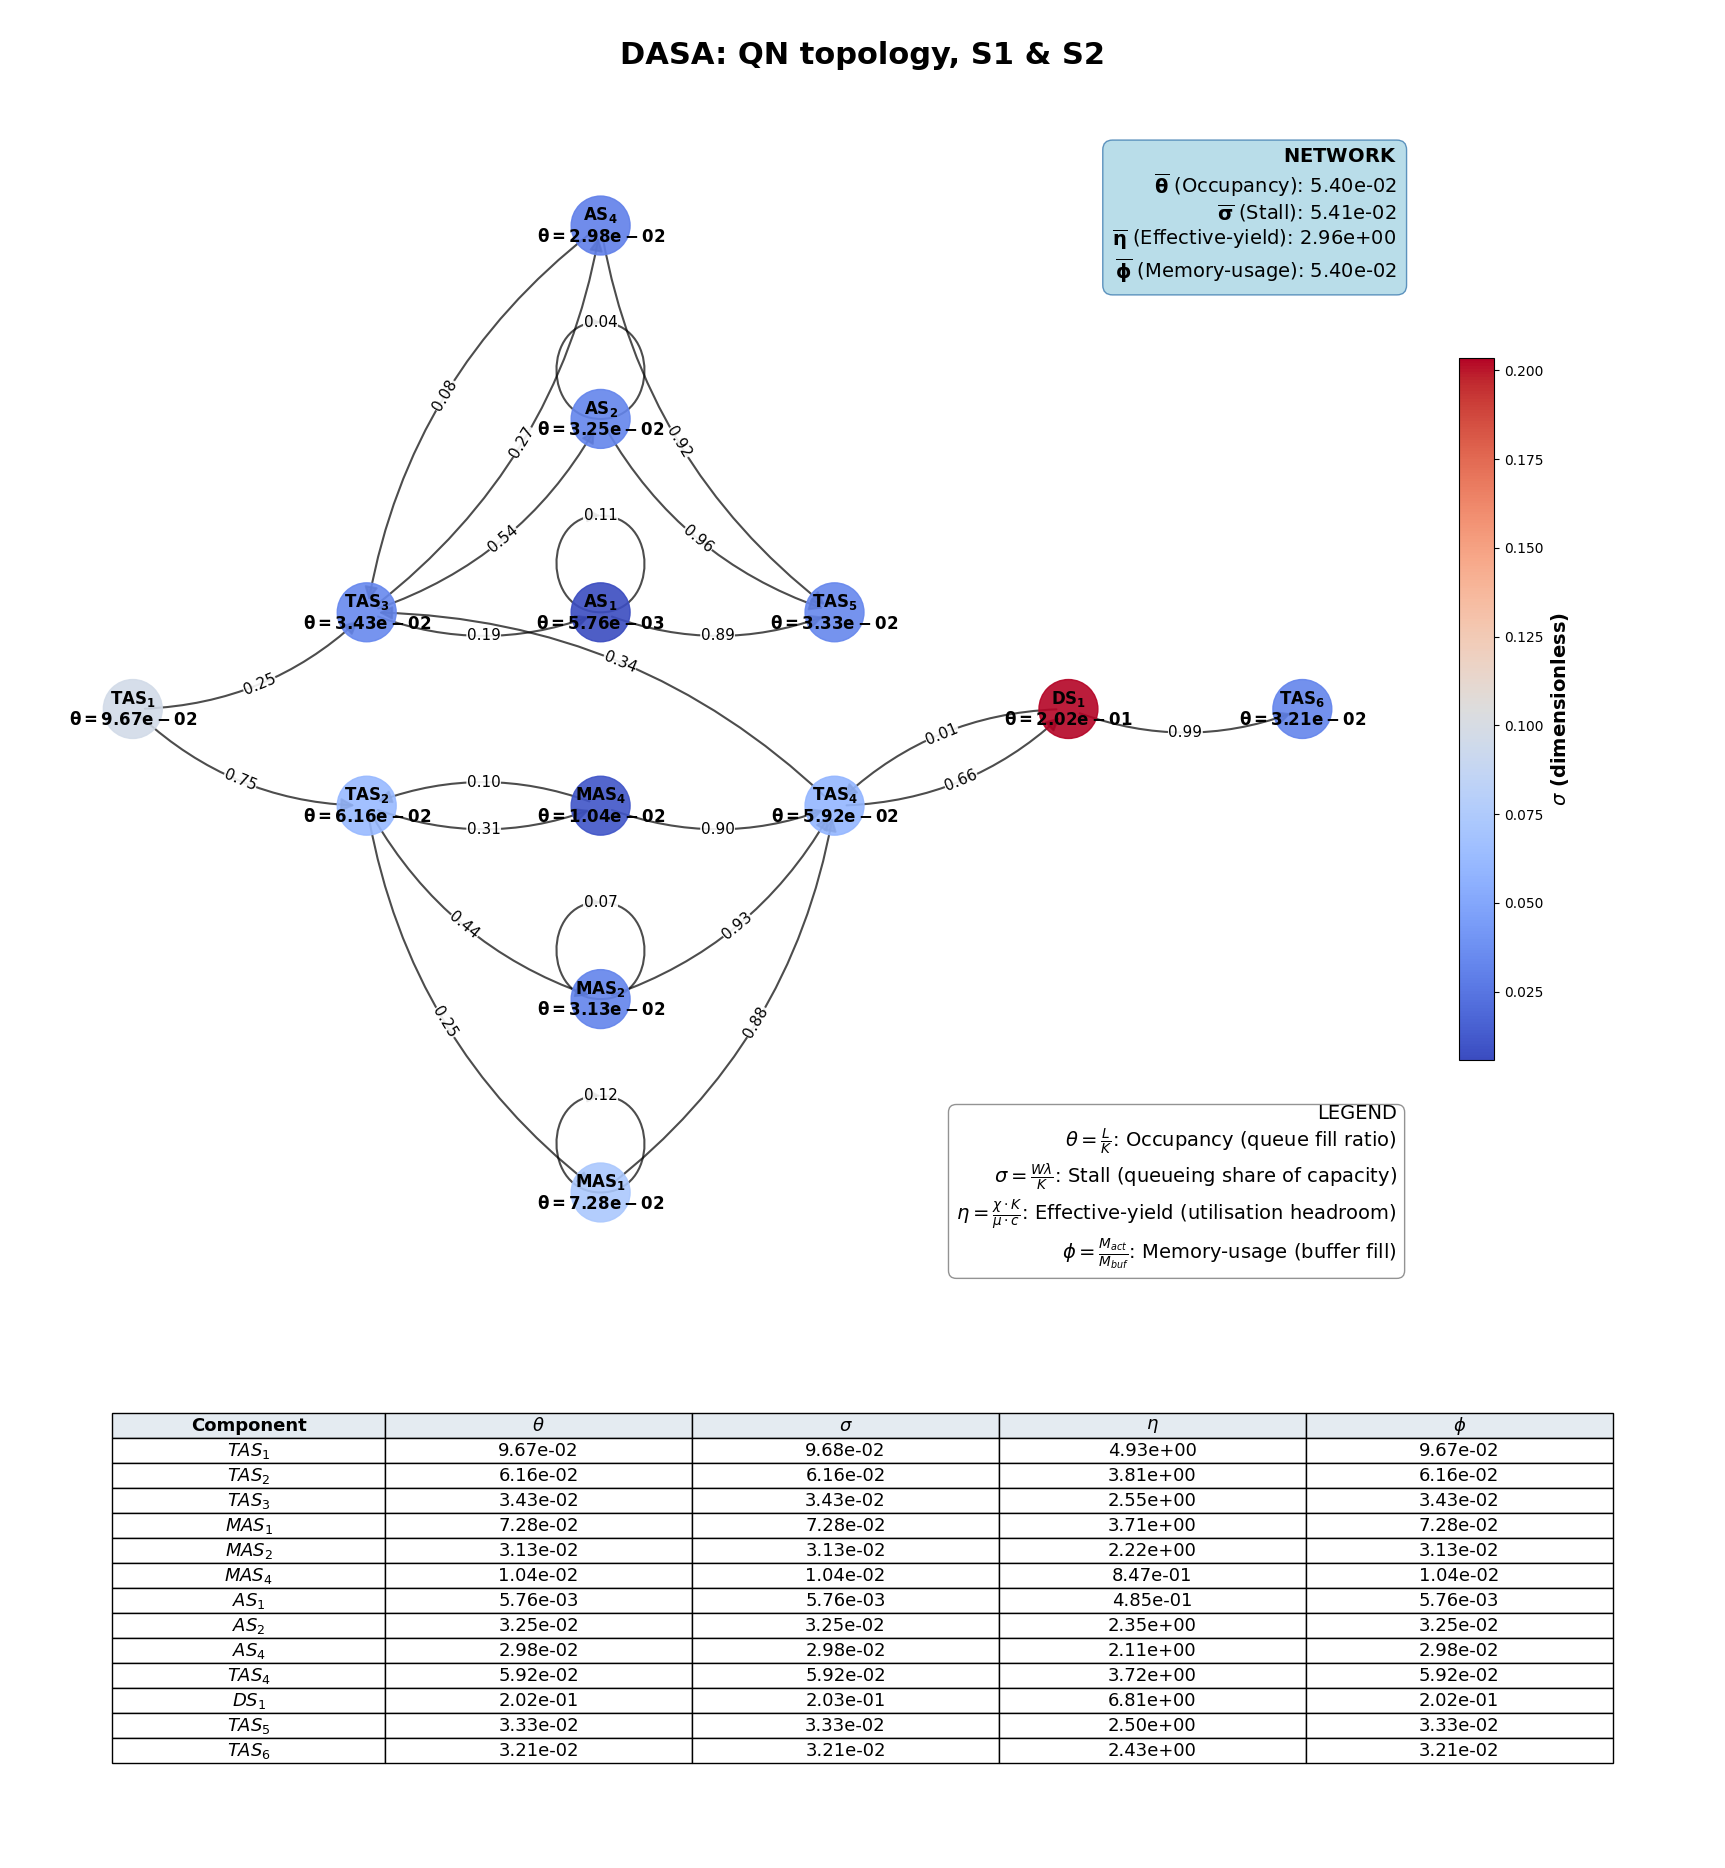

In [7]:
for a in ADAPTATIONS:
    plot_dim_topology(
        rout=results[a]["config"].routing,
        nds=nodes[a],
        color_by="sigma",
        title=f"DASA: QN topology, {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="topology.png",
    )


## 5. Per-node coefficient heatmap (before vs after)

One row = one artifact. One column = one coefficient ($\theta$, $\sigma$,
$\eta$, $\phi$). Colour scaled per-column across ALL scenarios so the same
cell is comparable across adaptations. One subplot per adaptation.


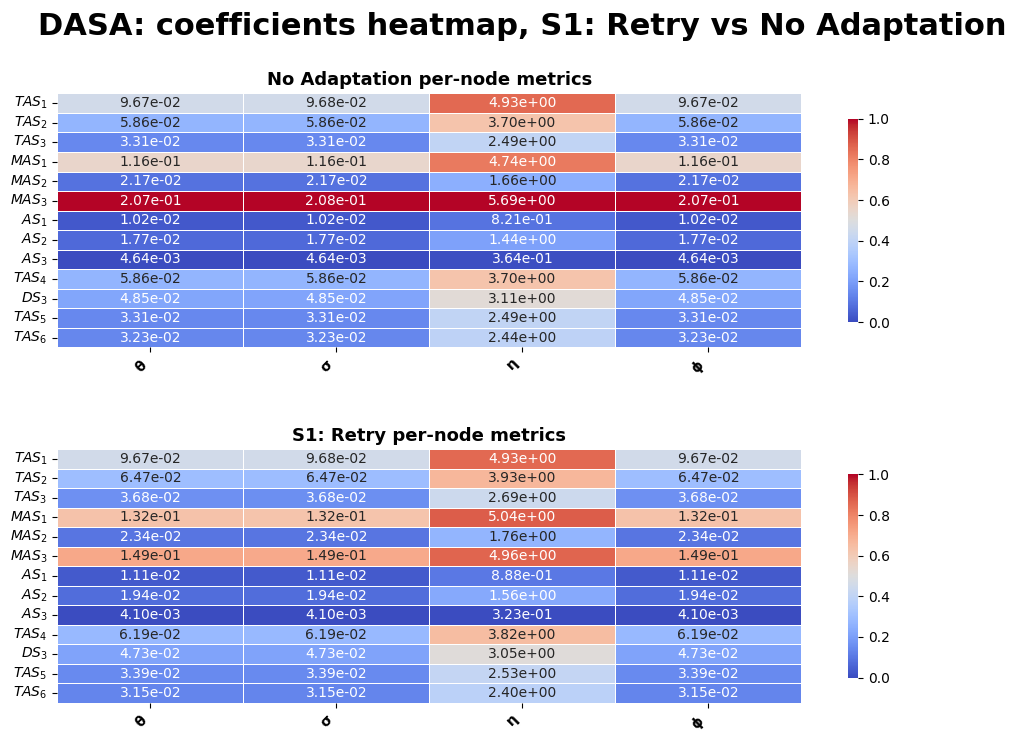

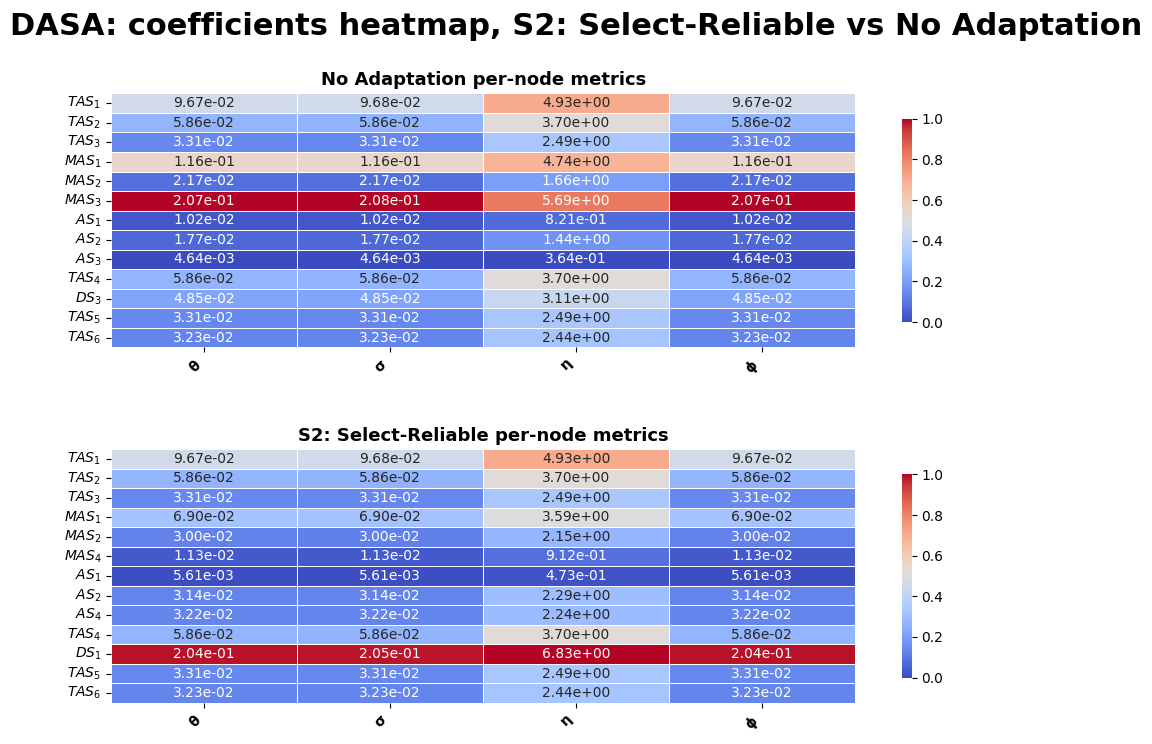

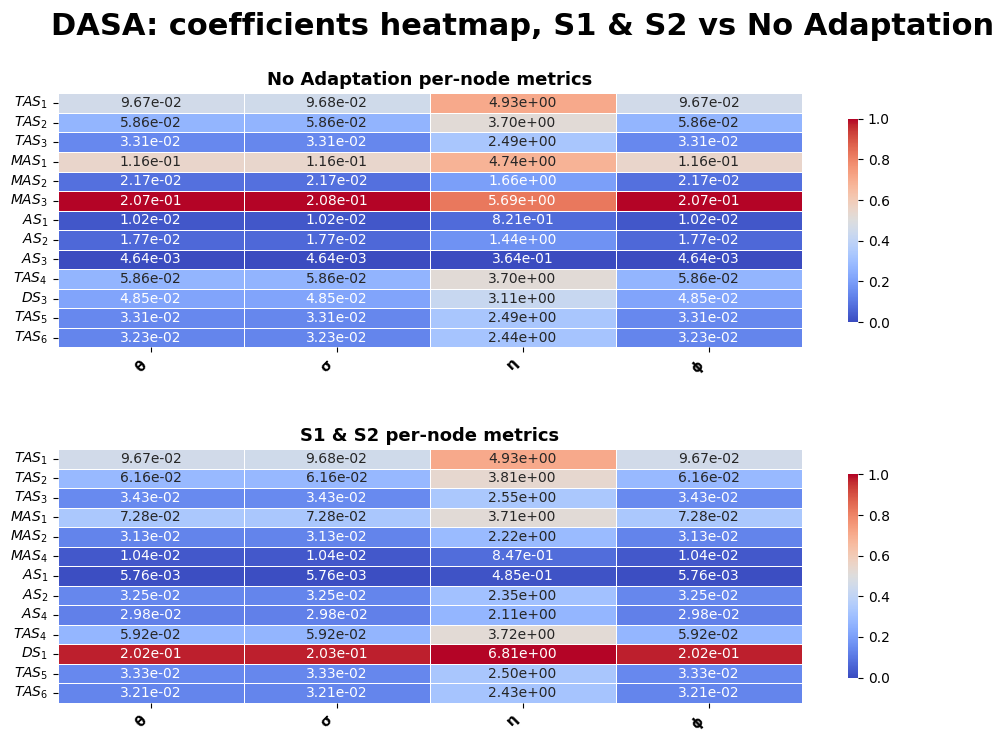

In [8]:
heat_metrics = ["theta", "sigma", "eta", "phi"]
heat_labels = [COEF_LABELS[m] for m in heat_metrics]

# plot_node_heatmap aligns rows positionally (iloc[i]); each panel's y-axis labels come from its own `key` column, so swap-slot rows show baseline's MAS_{3}/AS_{3}/DS_{3} and s2/aggregate's MAS_{4}/AS_{4}/DS_{1} at the same row position.
for a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[nodes["baseline"], nodes[a]],
        names=[DISPLAY["baseline"], DISPLAY[a]],
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"DASA: coefficients heatmap, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_heatmap_vs_baseline.png")


## 6. Per-node coefficient diffmap (vs baseline)

For every non-baseline adaptation, show the relative change
$(\text{other} - \text{dflt}) / |\text{dflt}|$ per artifact. Diverging
colour scale, zero-centred so improvements and degradations read with equal
intensity.


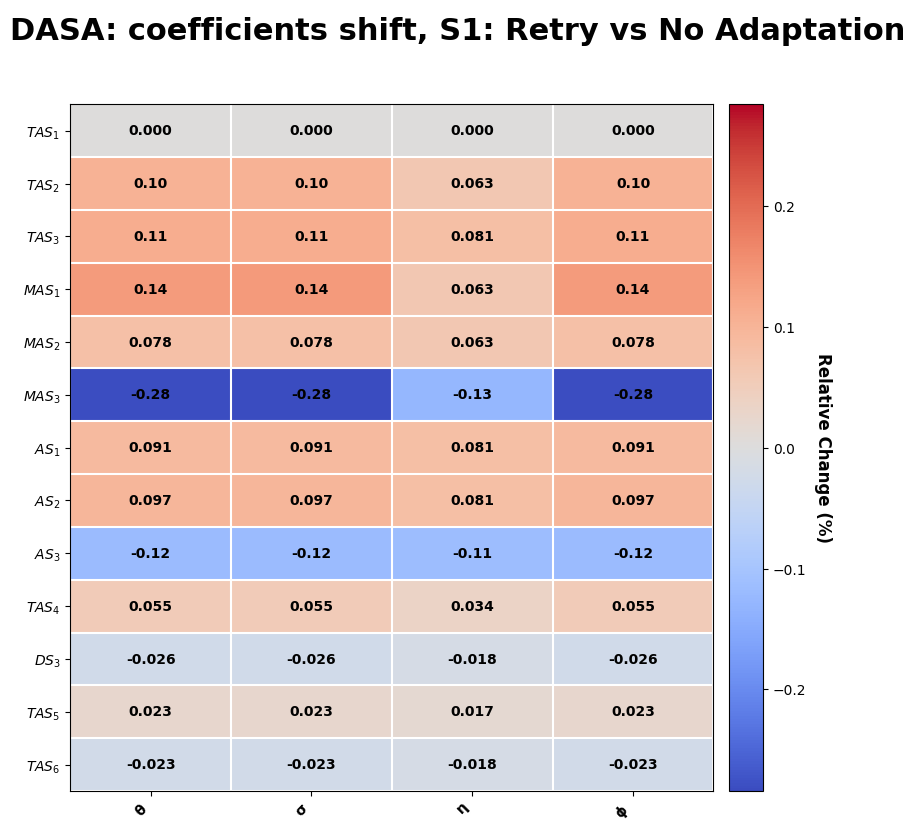

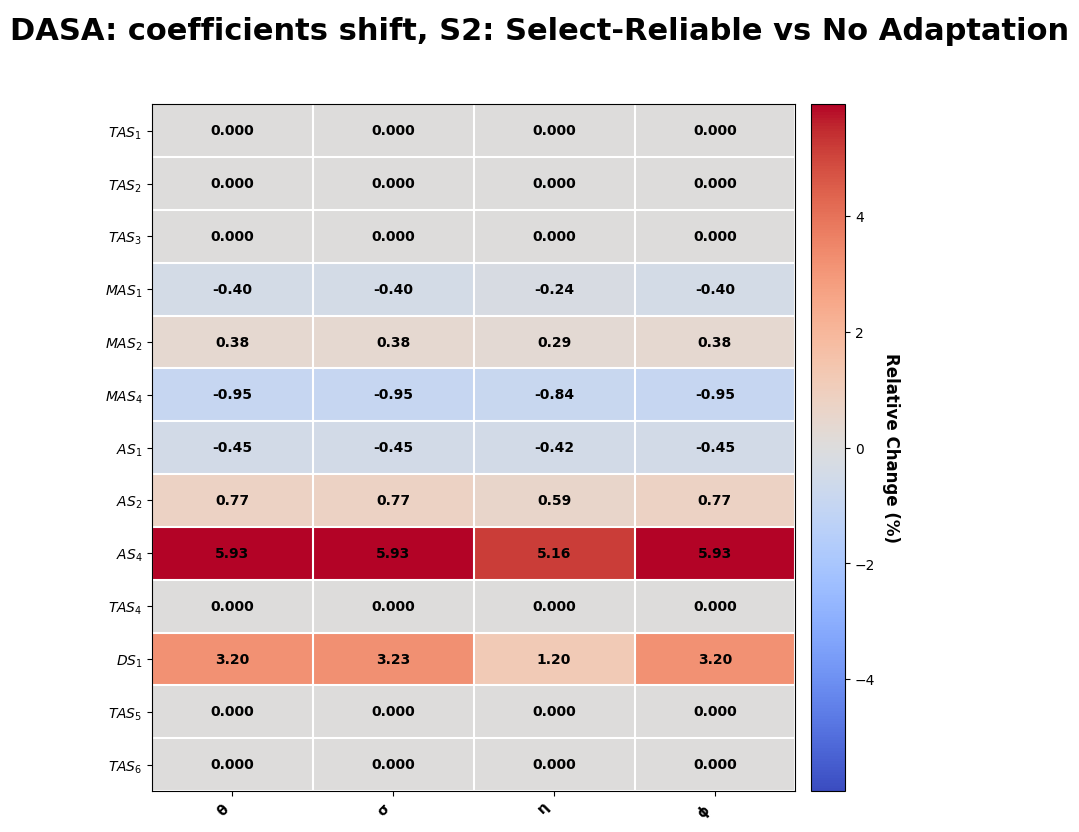

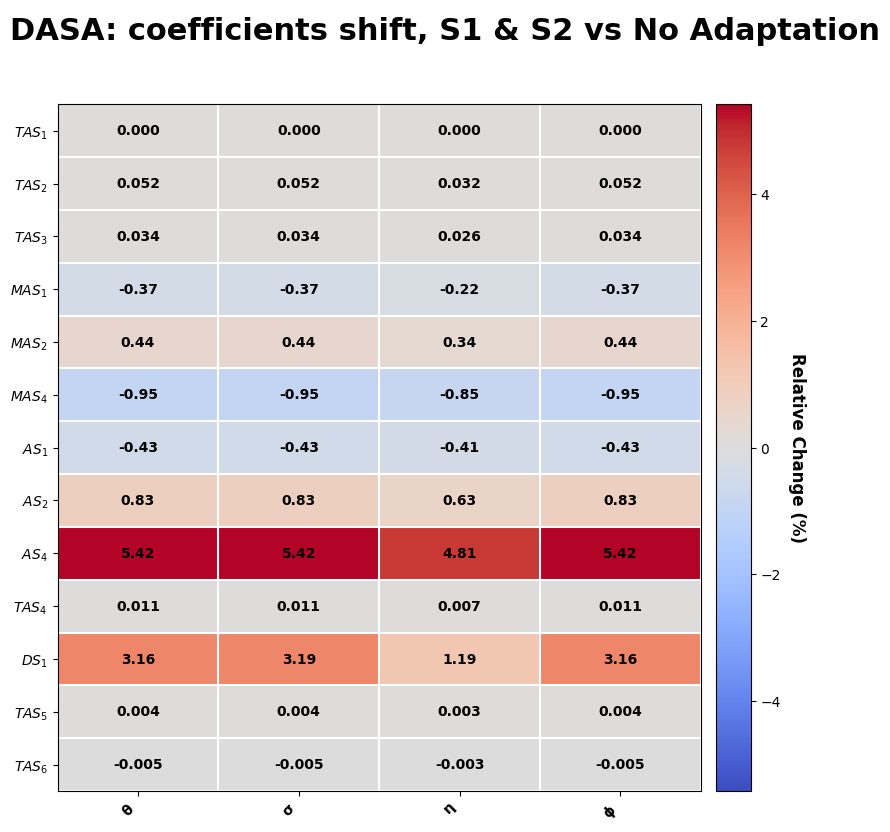

In [9]:
# positional-index inline delta (matches 01-analytic): align by slot since `key` may differ at swap slots
bl_nodes = nodes["baseline"]
for a in ["s1", "s2", "aggregate"]:
    ac_nodes = nodes[a]
    rows = []
    for i in range(len(ac_nodes)):
        b_row = bl_nodes.iloc[i]
        c_row = ac_nodes.iloc[i]
        row = {"key": c_row["key"]}
        for m in heat_metrics:
            b, c = float(b_row[m]), float(c_row[m])
            row[m] = ((c - b) / abs(b)) if b else 0.0
        rows.append(row)
    deltas = pd.DataFrame(rows)

    plot_node_diffmap(
        deltas=deltas,
        nodes=deltas["key"].tolist(),
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"DASA: coefficients shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png")


## 7. Network-wide coefficient bars

Headline comparison of the four coefficients across all four adaptations.
Linear y-axis (coefficients are O(1)); log scale would be misleading.


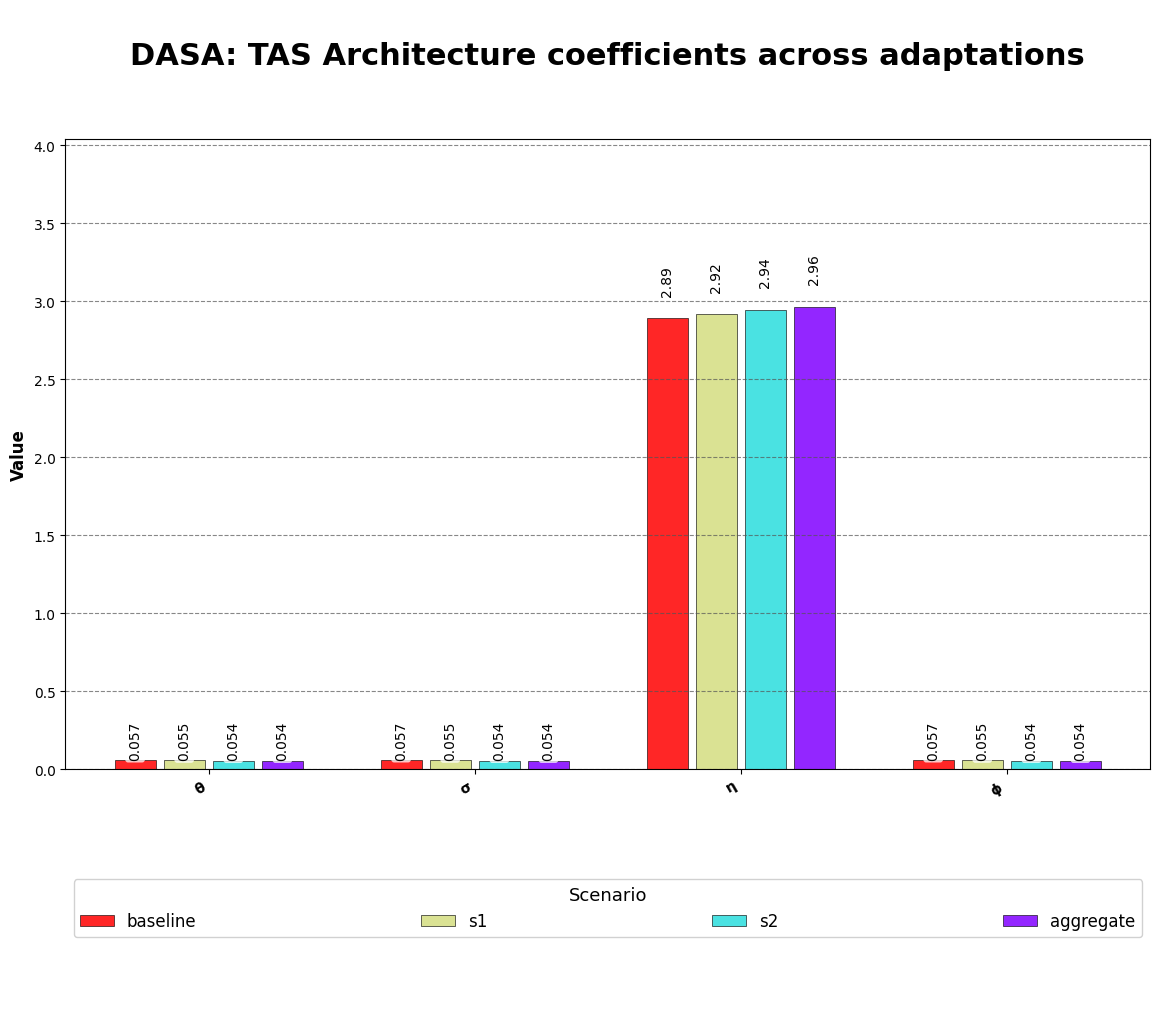

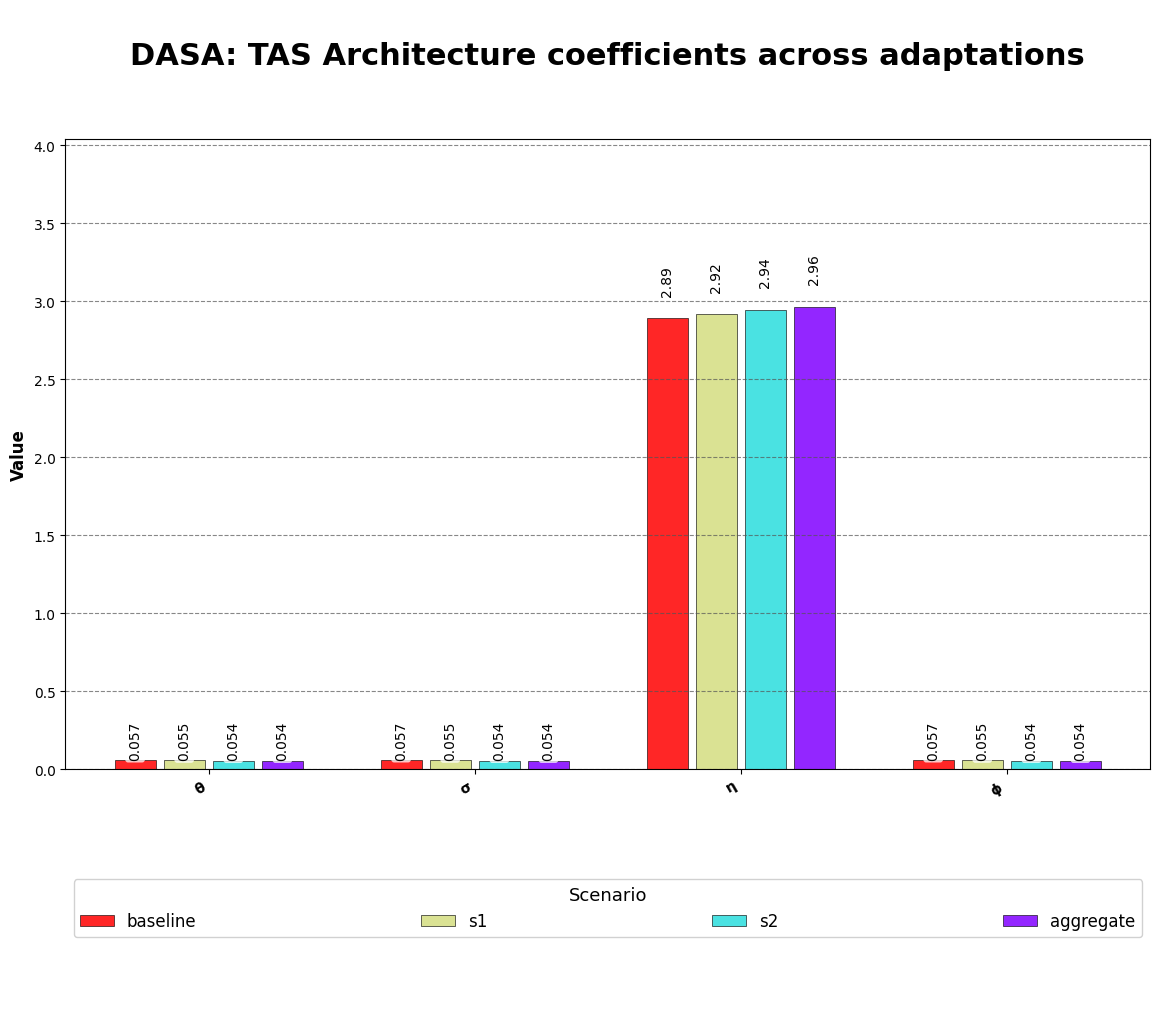

In [10]:
bar_metrics = ["theta", "sigma", "eta", "phi"]
bar_labels = [COEF_LABELS[m] for m in bar_metrics]

plot_arch_bars(
    nets=[nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    logscale=False,
    title="DASA: TAS Architecture coefficients across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png",
)


## 8. Network-wide delta (% change vs baseline)

Fractional change for each non-baseline adaptation. Colours semantic: green
when the coefficient decreases (generally an improvement: less occupancy,
less stall, less buffer pressure); red when it increases.


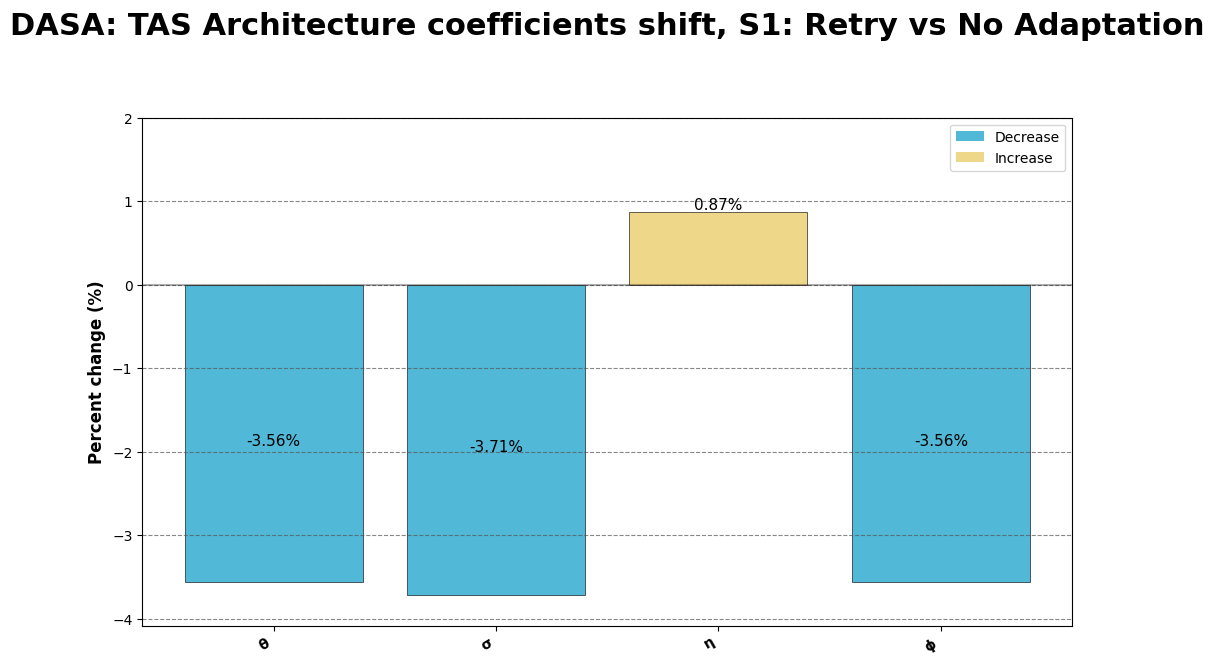

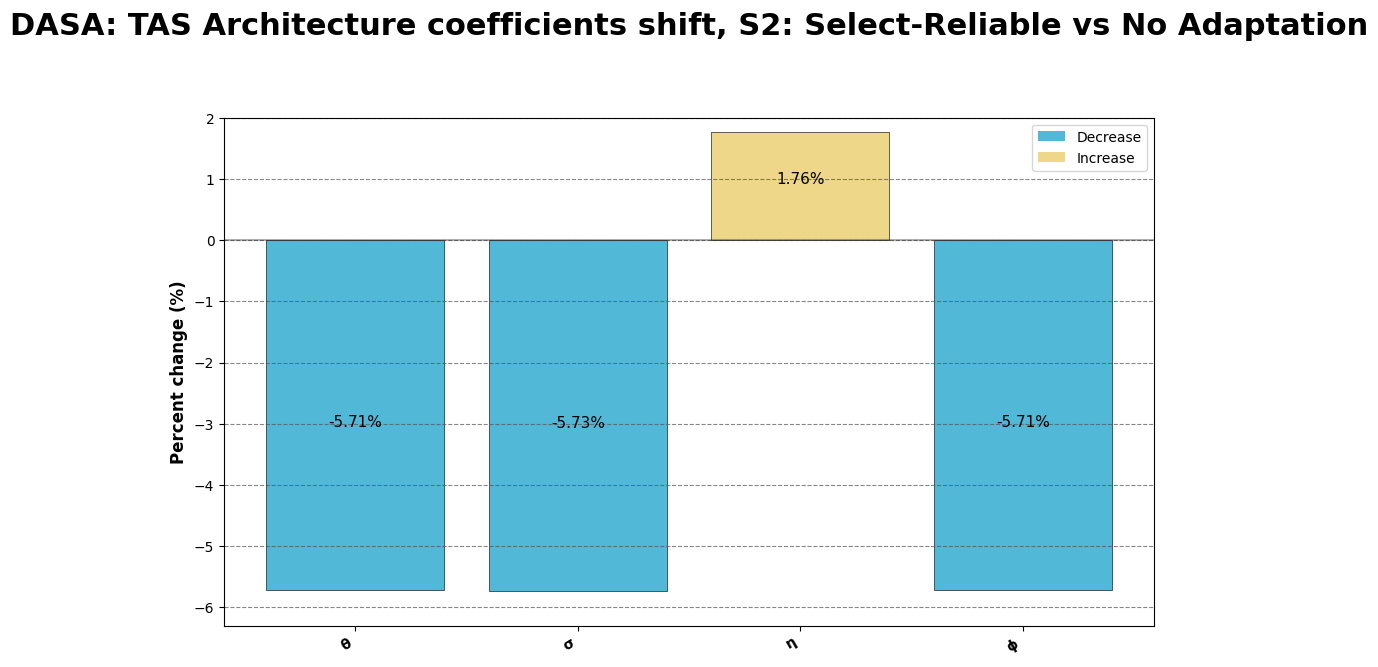

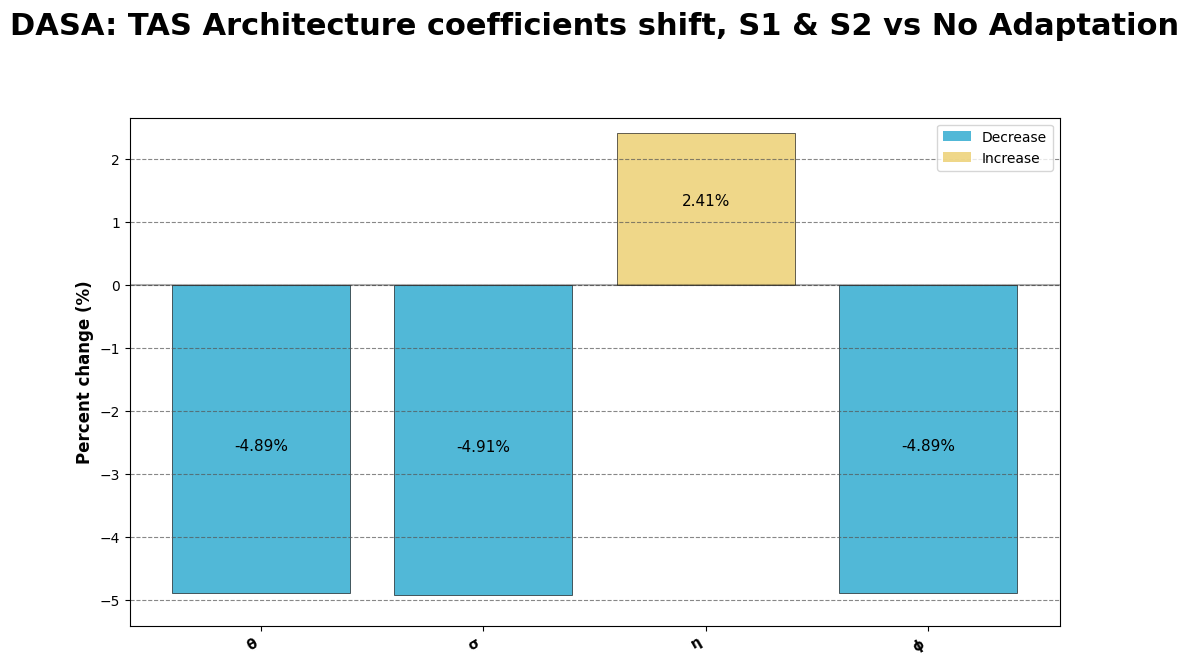

In [11]:
# inline delta-comprehension (matches 01-analytic): one fractional delta per metric per non-baseline adaptation
bl = nets["baseline"].iloc[0]
for a in ["s1", "s2", "aggregate"]:
    ac = nets[a].iloc[0]
    row = {
        m: (ac[m] - bl[m]) / bl[m] if bl[m] else 0.0
        for m in bar_metrics
    }
    plot_arch_delta(
        deltas=pd.DataFrame([row]),
        metrics=bar_metrics,
        labels=bar_labels,
        title=f"DASA: TAS Architecture coefficients shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png")


## 9. Top-3 most sensitive variables per coefficient (baseline)

Symbolic sensitivity at variable means. For each coefficient we show the
three variables with the largest $|\partial \text{coeff} / \partial x|$ on
the baseline $TAS_{1}$ artifact. Orientation (sign) is documented in
`notes/workflow.md`.


In [12]:
SAMPLE_ARTIFACT = "TAS_{1}"
sens = results["baseline"]["artifacts"][SAMPLE_ARTIFACT]["sensitivity"]

DERIVED_COEFFS = [
    (r"$\mathbf{\theta}$", "SEN_{\\theta_{TAS_{1}}}"),
    (r"$\mathbf{\sigma}$", "SEN_{\\sigma_{TAS_{1}}}"),
    (r"$\mathbf{\eta}$",   "SEN_{\\eta_{TAS_{1}}}"),
    (r"$\mathbf{\phi}$",   "SEN_{\\phi_{TAS_{1}}}"),
]

sens_rows = []
for label, key in DERIVED_COEFFS:
    vmap = sens.get(key, {})
    top3 = sorted(vmap.items(),
                   key=lambda kv: abs(kv[1]),
                   reverse=True)[:3]
    for v_sym, val in top3:
        sens_rows.append({
            "coefficient": label,
            "variable": v_sym,
            "d(coeff)/d(var)": val,
        })

pd.DataFrame(sens_rows)


,coefficient,variable,d(coeff)/d(var)
0,$\mathbf{\theta}$,L_{TAS_{1}},0.100000
1,$\mathbf{\theta}$,K_{TAS_{1}},-0.009672
2,$\mathbf{\sigma}$,W_{TAS_{1}},34.500000
3,$\mathbf{\sigma}$,K_{TAS_{1}},-0.009677
4,$\mathbf{\sigma}$,\lambda_{TAS_{1}},0.000280
5,$\mathbf{\eta}$,c_{TAS_{1}},-4.928571
6,$\mathbf{\eta}$,K_{TAS_{1}},0.492857
7,$\mathbf{\eta}$,\chi_{TAS_{1}},0.014286
8,$\mathbf{\phi}$,M_{act_{TAS_{1}}},0.000094
9,$\mathbf{\phi}$,M_{buf_{TAS_{1}}},-0.000009


## Summary

Dimensional analysis produces the same four derived coefficients per
artifact under every adaptation. **Pi-group expressions are invariant**
across adaptations (same variable set, different setpoints); this is the
Buckingham guarantee.

The dimensional method does **not** produce R1 / R2 verdicts: those are
operational thresholds (failure rate / response time) and belong to
`analytic` and `stochastic`. `comparison.ipynb` will triangulate the three
methods in the last notebook of the pipeline.

Configuration-sweep yoly diagrams (showing the full coefficient cloud across
a $(\mu, c, K)$ grid) live in `yoly.ipynb`; Phase 3b/c of the build plan.
